In [2]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
CUDA_LAUNCH_BLOCKING=1
def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values


cuda:1


In [4]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  # Number of grid cells in the x direction
nx,ny=3,3  # Gauss points per cell in the x direction
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 # On boundary Gamma

num_batches_gauss=1
b_n=15
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) # Collect data on boundary Gamma
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.5,0.5])
number_gene=50
eps=0.1
batch_number_rec_mea,mea=2,1
cupy_device = device.index if device.type == "cuda" else 0
S_int_true_circle,F_mea_b_circle,F_mea_db_x1_circle,F_mea_db_x2_circle=generate_data.boundary_data_circle(kk,number_gene,points_b,f_circle,x_left,x_right,y_below,y_upper,center_true,r_true,eps,mea,batch_number_rec_mea,device,cupy_device)
F=inverse_solver.F(F_mea_b_circle,F_mea_db_x1_circle,F_mea_db_x2_circle)

cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) # Create the initial grid
initial_cells=copy.deepcopy(cells) # Make a copy
R_m=20
r_low,r_upper=0.18,0.2
b_below,b_upper=-0.51,-0.49


In [5]:
M=1600
af="Tanh"   # Initial activation setting
R_m=20
cupy_device = device.index if device.type == "cuda" else 0
models = net_2d.local_rep(2, 2, 1, M, tau_x_min, tau_x_max,tau_y_min, tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],R_m,af,[],device).to(device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


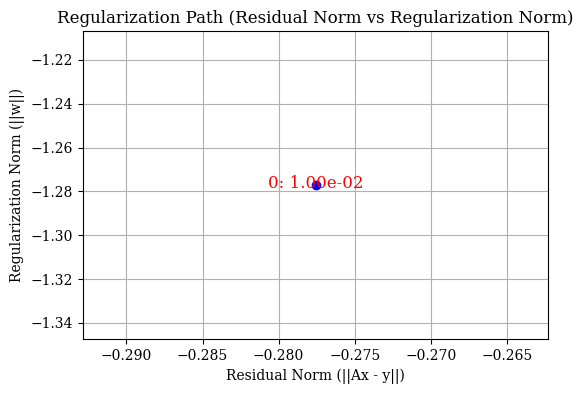

第 0 次迭代的train误差：
第 0 次迭代的泛化误差：


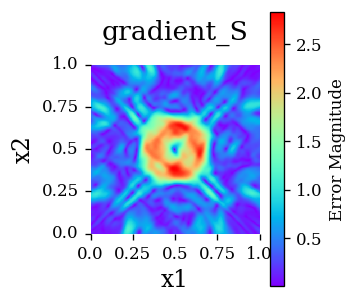

S_l_inf= 2.7422805716675063 S_L_2= 0.2881140200554032 S_l_2= 0.8164293215334825


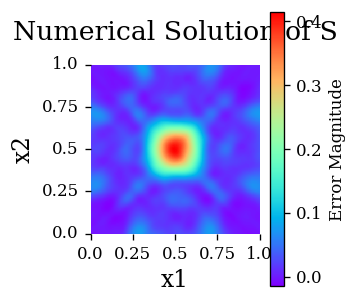

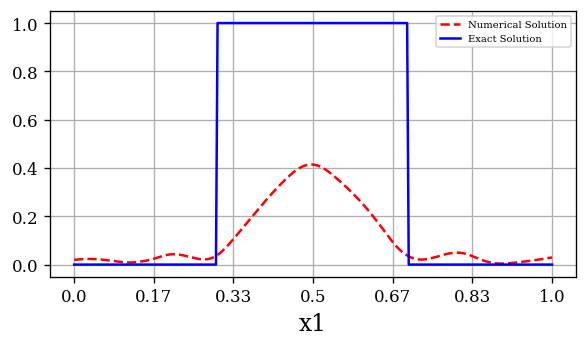

第 0 次自适应网格细分 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


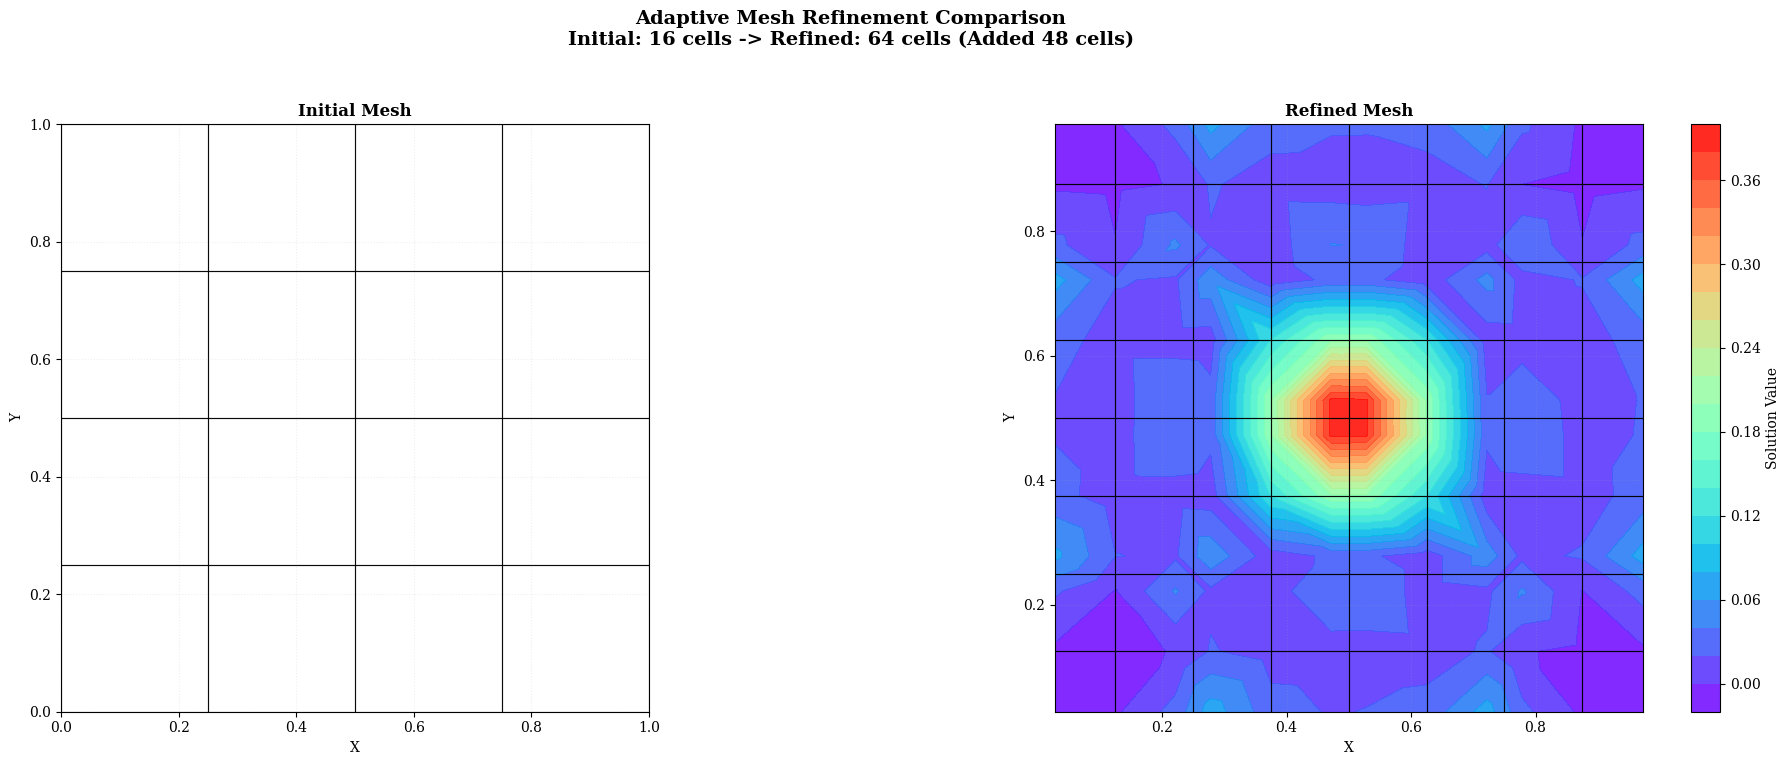

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


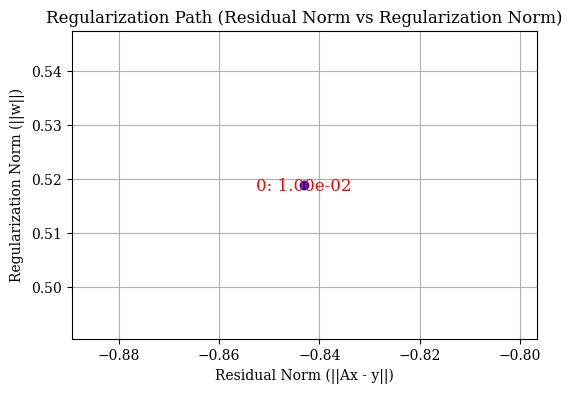

第 1 次迭代的train误差：
第 1 次迭代的泛化误差：


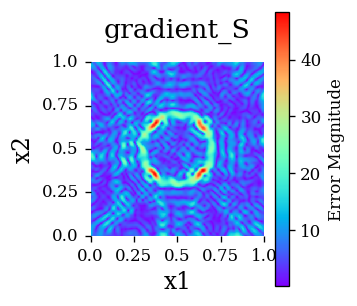

S_l_inf= 2.7487926854391502 S_L_2= 0.1320860426647593 S_l_2= 0.37429250466914116


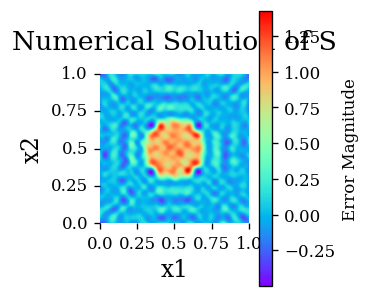

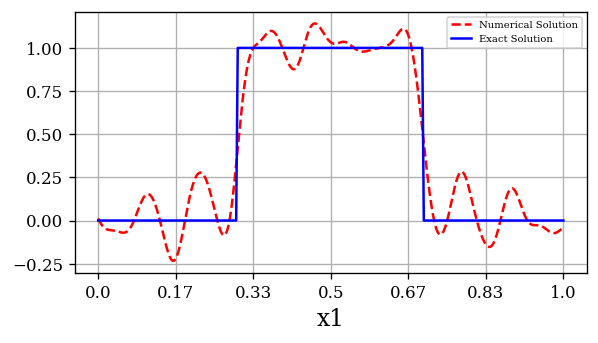

第 1 次自适应网格细分 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


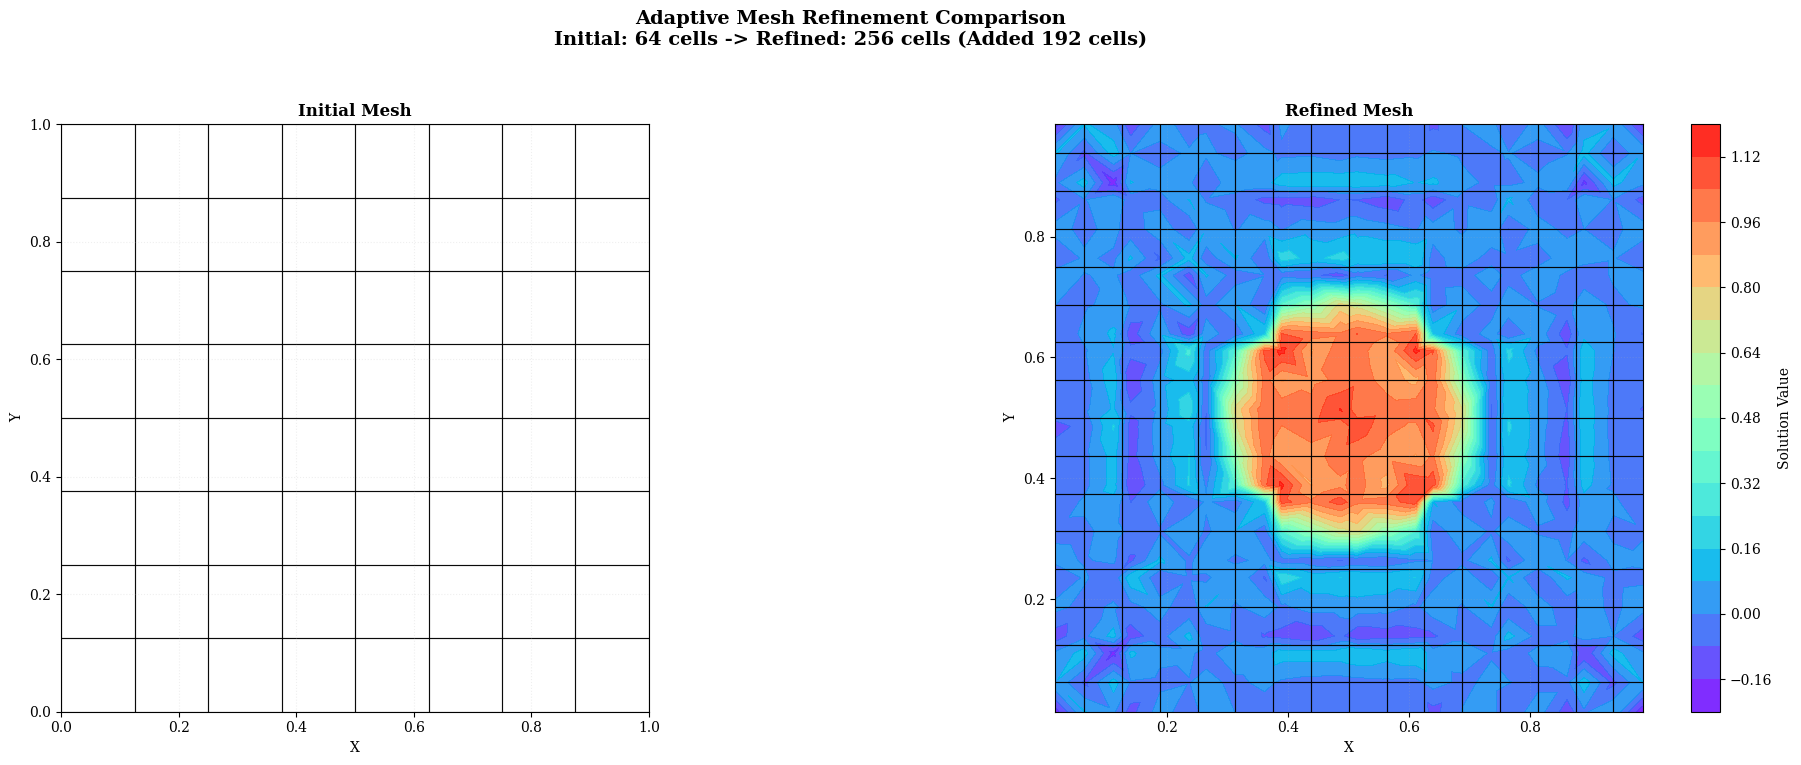

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


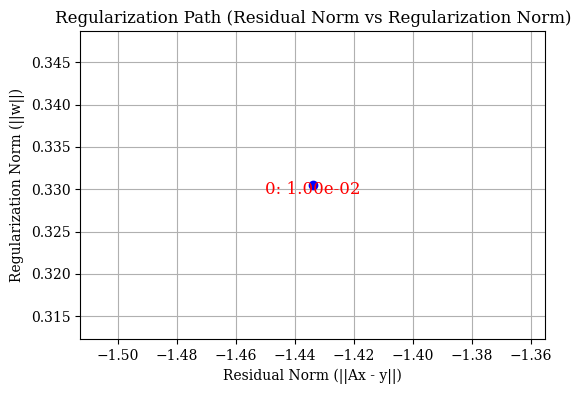

第 2 次迭代的train误差：
第 2 次迭代的泛化误差：


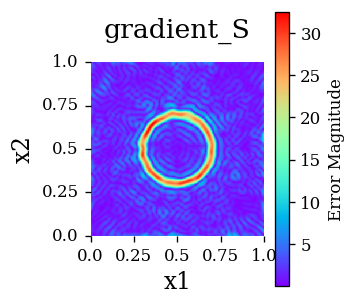

S_l_inf= 1.5959015842811544 S_L_2= 0.06899500394012502 S_l_2= 0.1955112918323248


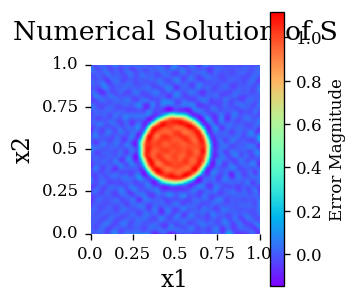

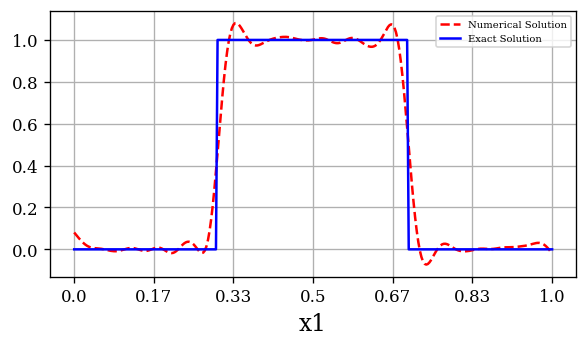

第 2 次自适应网格细分 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


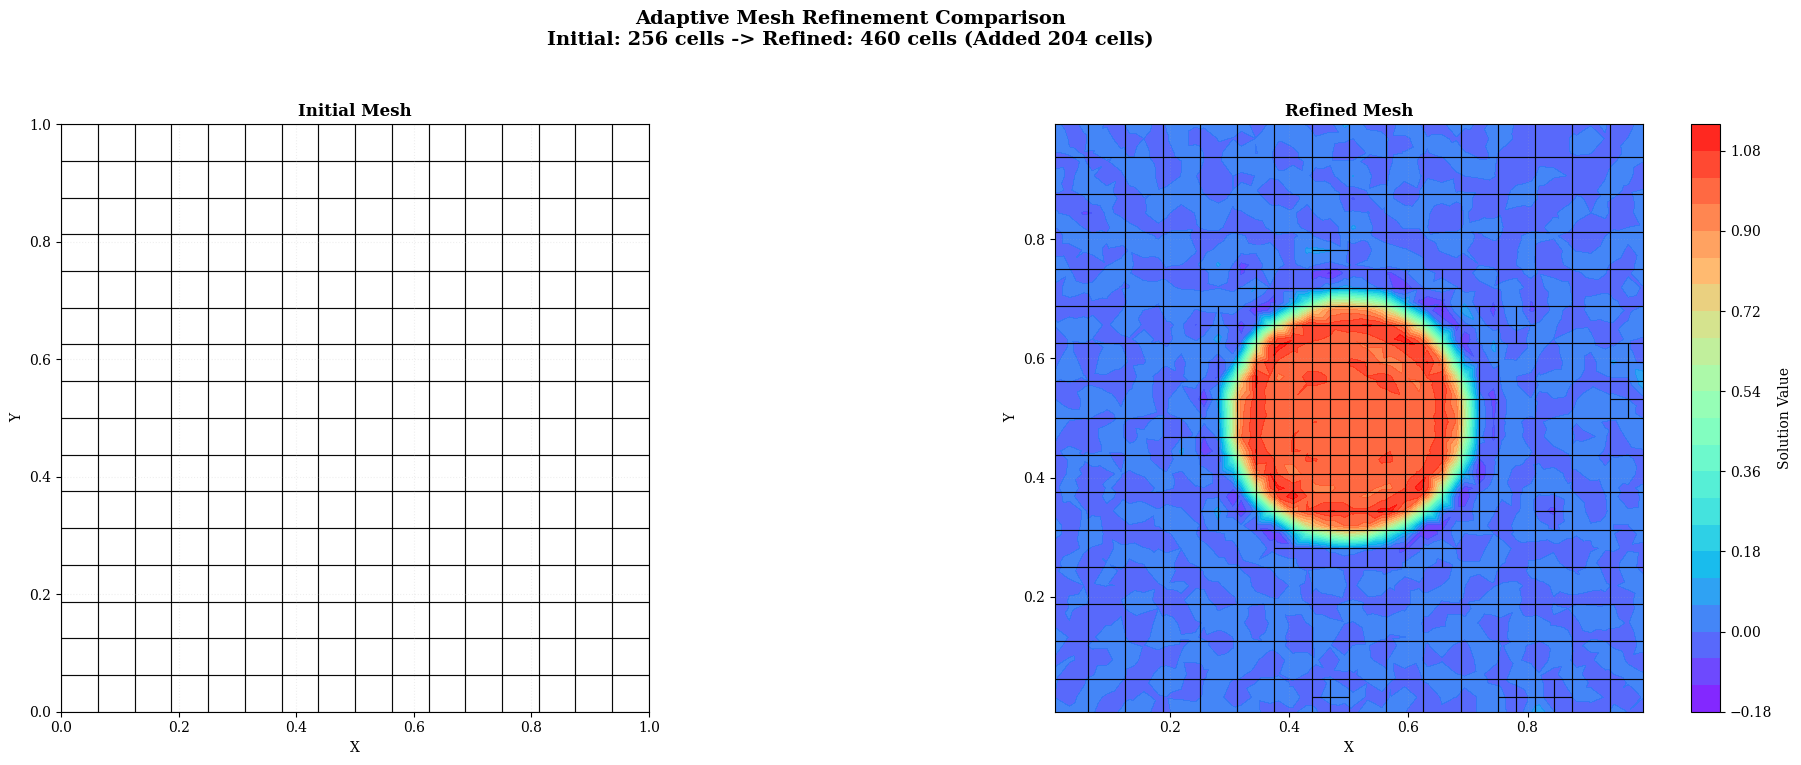

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


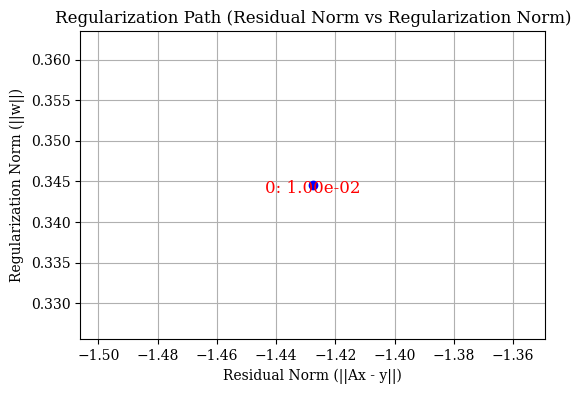

第 3 次迭代的train误差：
第 3 次迭代的泛化误差：


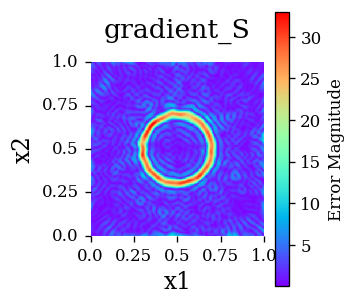

S_l_inf= 1.5819542721627635 S_L_2= 0.06904071907533735 S_l_2= 0.1956408349098121


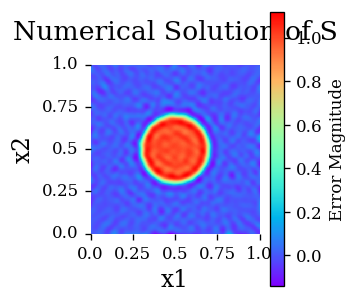

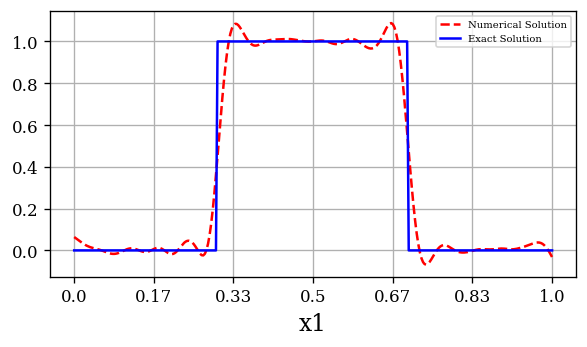

第 3 次自适应网格细分 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


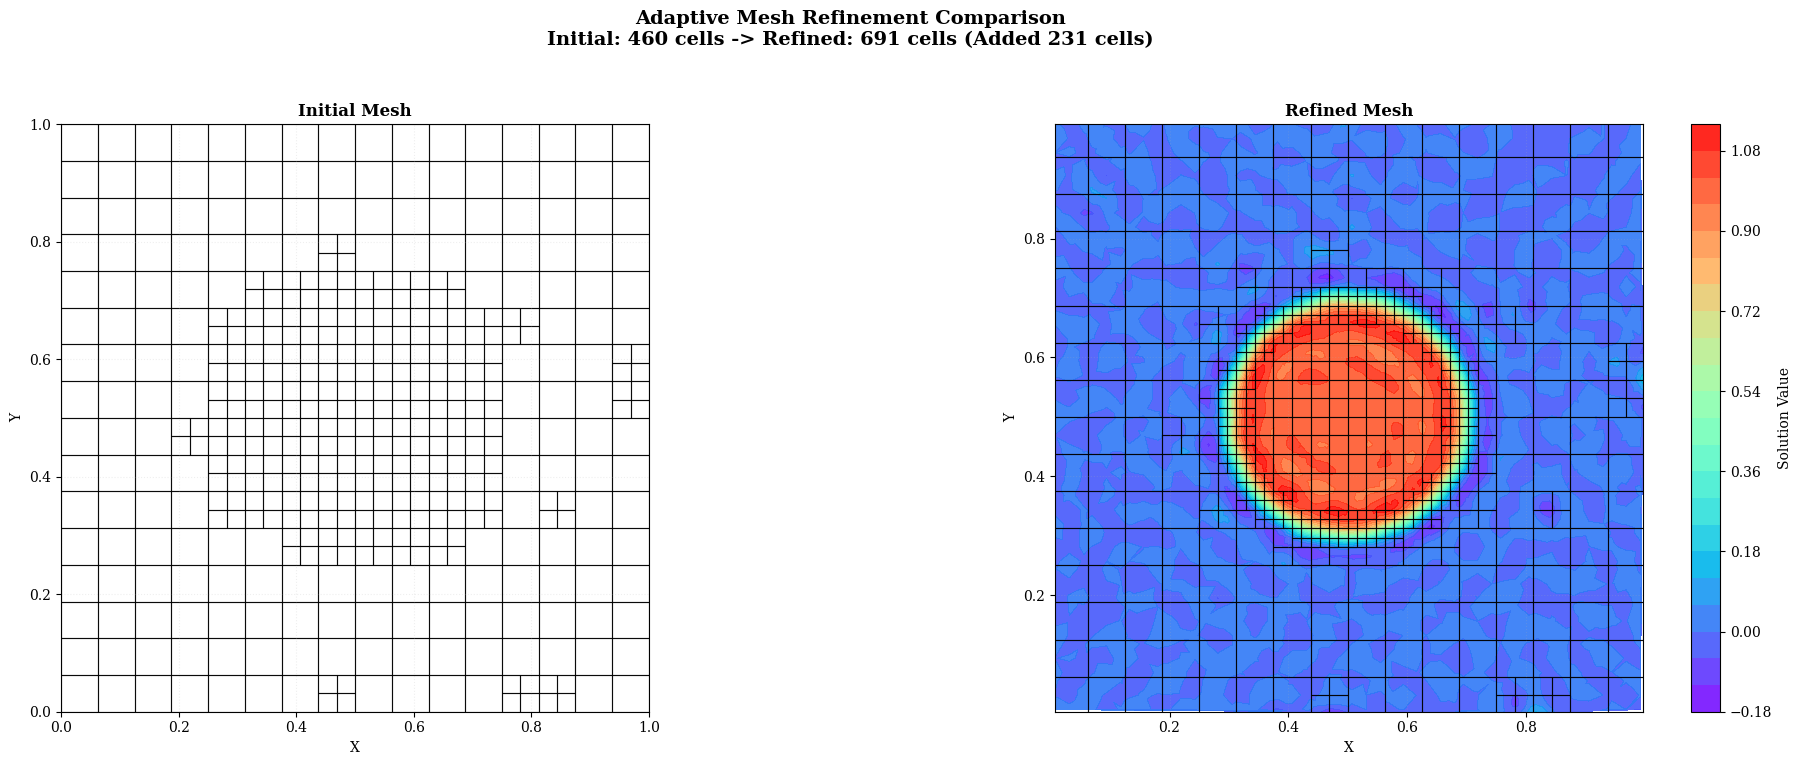

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


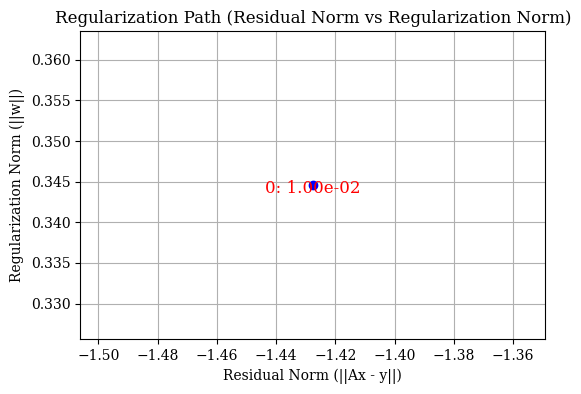

第 4 次迭代的train误差：
第 4 次迭代的泛化误差：


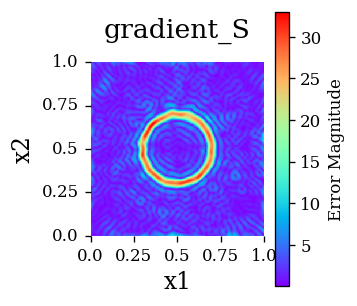

S_l_inf= 1.5818960981062697 S_L_2= 0.06903987786594201 S_l_2= 0.19563845117292983


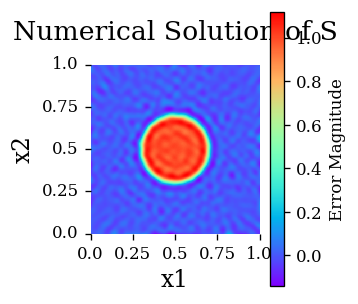

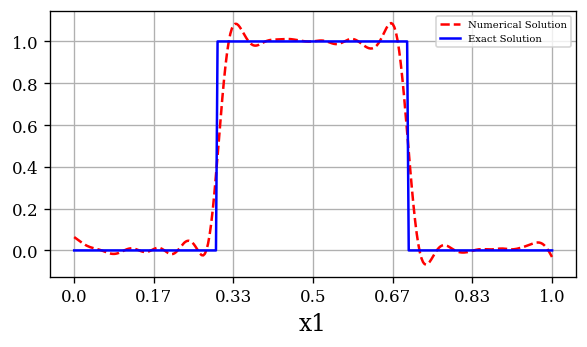

在第 4 次迭代结束


In [6]:
iter_int= 5
Ix,Iy=4,4  # Number of grid cells in the x direction
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"

refine_threshold_S=1/100
refine_threshold_grad=1/300
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_l2,S_num_store=main.ada_int_fix(iter_int,delta,cells,nx,models,M,af,kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_low,r_upper,center_true,r_true,f_circle,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,current_maxiter,max_level)


In [7]:
len(cells_store[-1])

691

In [14]:
# Save cells_store
import pickle
with open('./Noise/noise=10%/cells_store_last.pkl', 'wb') as f:
    pickle.dump(cells_store[-1], f)

In [9]:
np.save('./Noise/noise=10%/g_S.npy', g_S)
np.save('./Noise/noise=10%/S_num_store.npy', S_num_store)

Number of detected clusters: 1
  CV of S_num: 0.268
Cluster 0: AR=1.00
  Res_Rect=0.084 vs Res_Ellip=0.023
  -> Decision: Circle (Sigmoid)


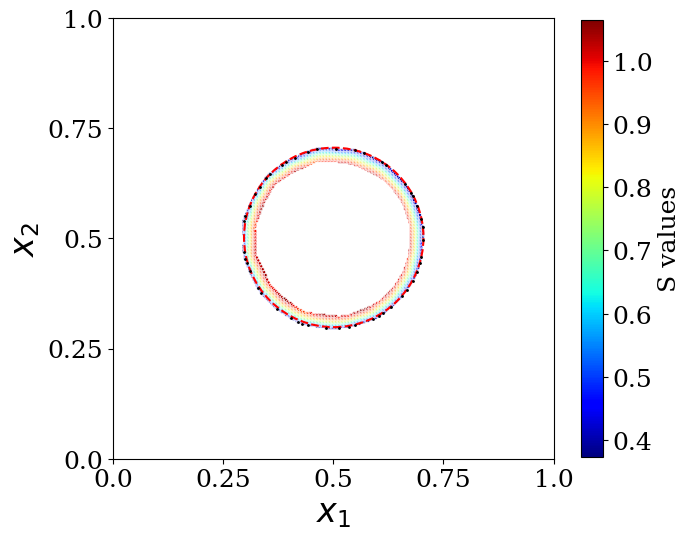

In [10]:
import bound_detect
from importlib import reload
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=5.0
mini_samples=20
para_abs=3
para_grad=3
results=bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./Noise/noise=10%", output_filename="plot.png", eps_mode="grid_scaled")

In [15]:
results

[{'cluster_id': 0,
  'shape': 'Circle',
  'params': {'center': array([0.50114674, 0.5022233 ]),
   'radius': np.float64(0.20364221812521327)},
  'profile': 'Sigmoid'}]

In [12]:
center=results[0]['params']['center']
r = results[0]['params']['radius']

In [16]:
r_min=r*(1-0.1)
r_max=r*(1+0.05)
K_min=1000
K_max=20000
b1_min=-center[0]*(1+0.05)
b1_max=-center[0]*(1-0.05)
b2_min=-center[1]*(1+0.05)
b2_max=-center[1]*(1-0.05)
models1=models
models2= net_2d.local_rep(2,2,1,1600,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_min,r_max,b1_min,b1_max,b2_min,b2_max,[],[],[],[],[],[],[],[],K_min,K_max,1,"sigmoid","circle",device).to(device)
af="mix"
sum_mat,all_g_p1,all_g_n,cells_copy1,_,_=matrix_assemble.mat_assemble(cells_store[-1],models1,models2,[],"mix","circle",[],kk,0,points_b,0,device,cupy_device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


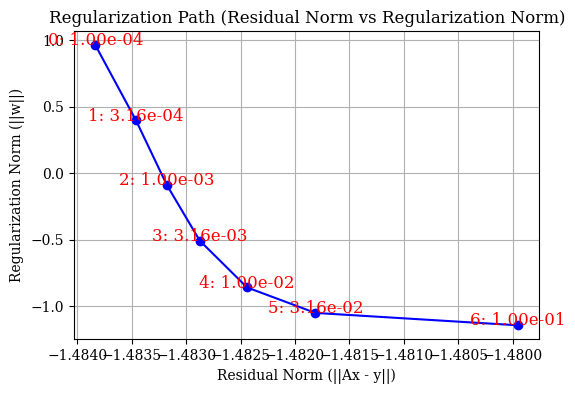

In [17]:
lamb_regu=np.logspace(-4,-1,7,endpoint=True)
res,reg_norm,w_store=inverse_solver.L_curve(sum_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) # Solve first

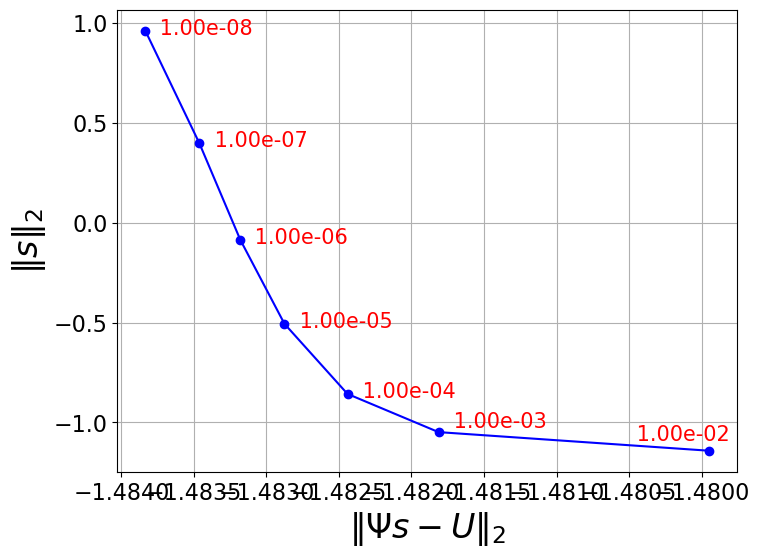

In [26]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcdefaults()
plt.figure(figsize=(8, 6))
log_res=np.log10(res.reshape(-1))
log_reg_norm=np.log10(reg_norm.reshape(-1))
plt.plot(log_res,log_reg_norm , marker='o', linestyle='-', color='b', label="Regularization Path")
iter=len(lamb_regu)
for i in range(iter):
    if i==iter-1:
        plt.text(log_res[i]-0.0002, log_reg_norm[i]+0.05,   f" {lamb_regu[i]**2:.2e}", fontsize=15, ha='center', color='red')
    elif i==iter-2:
        plt.text(log_res[i]+0.0004, log_reg_norm[i]+0.02,   f" {lamb_regu[i]**2:.2e}", fontsize=15, ha='center', color='red')
    else:
        plt.text(log_res[i]+0.0004, log_reg_norm[i]-0.018,   f" {lamb_regu[i]**2:.2e}", fontsize=15, ha='center', color='red')
plt.tick_params(axis='both', labelsize=16)
plt.xlabel("$\|\Psi s-U\|_2$",fontsize=24)
plt.ylabel("$\|s\|_2$",fontsize=24)
plt.grid(True)
plt.savefig("./Noise/noise=10%/L_curve.pdf",dpi=300, bbox_inches='tight')
plt.show()


lamb: 0.0001
S_l_inf= 1.6248583757722161 S_L_2= 0.04891934850095152 S_l_2= 0.13862286361077353


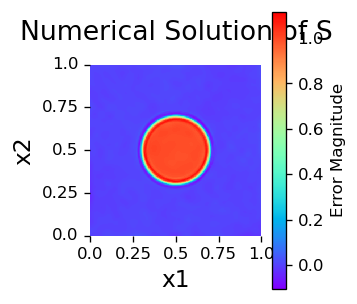

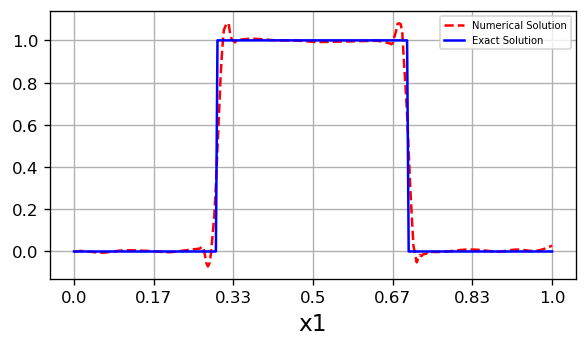

In [27]:
lamb=lamb_regu[4]**2
print('lamb:',lamb)
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=error_general_2d.test(models1,models2,[],M,Qx,Qy,w_store[:,4],"mix","circle",[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],center_true,r_true,f_circle,0,device)


In [28]:
torch.save(models1,"./Noise/noise=10%/models0_d1d3.pth")

In [29]:
torch.save(models2,"./Noise/noise=10%/models1_sig_33_1600_d1d3.pth")

In [30]:
import pickle

with open("./Noise/noise=10%/cells_store_last.pkl", "wb") as f:
    pickle.dump(cells_store[-1], f)

In [31]:
np.save("./Noise/noise=10%/S_num_1600*2_10-30",S_test_num)
np.save("./Noise/noise=10%/all_mat",sum_mat)
np.save("./Noise/noise=10%/w_store",w_store)
np.save("./Noise/noise=10%/F_mea_b",F_mea_b_circle)
np.save("./Noise/noise=10%/F_mea_db_x1",F_mea_db_x1_circle)
np.save("./Noise/noise=10%/F_mea_db_x2",F_mea_db_x2_circle)

In [32]:
parameters0 = {
    "I_grid":Ix,
    "gauss_n":nx,
    "number_gene":number_gene,
    "noise":eps,
    "k": kk,
    "M0": 1600,
    "M1": 1600,
    "Tanh_Rm":20,
    "Gauss_R_m": R_m,
    "refinement_stats_store":refinement_stats_store,
    "points_number_ada:":point_number,
    "center":center,
    "r":r,
    "r_min": r_min,
    "r_max": r_max,
    "b1_min": b1_min,
    "b1_max": b1_max,
    "b2_min": b2_min,
    "b2_max": b2_max,
    "K_min": K_min,
    "K_max": K_max,
}

In [33]:
n_integral=len(cells_store[-1])*9
print('n_integral:',n_integral)
print('center:',center)
print('r:',r)
print('S_l2[-1]:',S_l2[-1])
print('lamb_regu:',lamb)
print('S_l21:',S_l_21)

n_integral: 6219
center: [0.50114674 0.5022233 ]
r: 0.20364221812521327
S_l2[-1]: 0.19563845117292983
lamb_regu: 0.0001
S_l21: 0.13862286361077353
